# Model Attempt 2 — EfficientNet-B0 Gaze Estimation
**Architecture**: EfficientNet-B0 → theta/phi (radians)  
**Labels**: θ = arcsin(−gy), φ = atan2(−gx, −gz), normalised to [−1, 1]  
**Data**: MPIIGaze Normalised (real, right eyes only) + UnityEyes2 (synthetic, right eye)  
**Loss**: Huber Loss (δ = 0.1)  
**Split**: Subject-level (11 train / 2 val / 2 test subjects), synthetic data in train only, seed 42

---
### Workflow
1. Mount Drive & install deps  
2. Load CSVs → sample 12K real + 12K synthetic (right eye only)  
3. Dataset class with augmentation  
4. EfficientNet-B0 model definition  
5. Training loop with early stopping  
6. **Ratio Experiment** — sweep synthetic fraction 0 % → 100 % (keeps total = 24 K)  
7. Evaluation — MAE°, RMSE°, R², per-axis analysis  
8. Sectional accuracy — 4 × 3 imaginary 1080p display grid  
9. Export best model to ONNX

## 1. Environment Setup

In [28]:
# Install / upgrade as needed on Colab
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "timm", "scipy", "torchmetrics"], check=True)

from google.colab import drive
# drive.mount('/content/drive')
drive.mount("/content/drive", force_remount=True)
import os, zipfile, shutil

# ── Paths (edit these to match your Drive layout) ──────────────────────────
DRIVE_ROOT     = '/content/drive/MyDrive/FYP_3DML'
UNITY_ZIP      = f'{DRIVE_ROOT}/unity_crops.zip'
MPII_ZIP       = f'{DRIVE_ROOT}/mpii_crops.zip'
UNITY_CSV      = f'{DRIVE_ROOT}/unity_labels.csv'   # uploaded separately to Drive
MPII_CSV       = f'{DRIVE_ROOT}/mpii_labels.csv'    # uploaded separately to Drive

EXTRACT_UNITY  = '/content/crops/unity'
EXTRACT_MPII   = '/content/crops/mpii'

# ── Extract if not already done ─────────────────────────────────────────────
def maybe_unzip(zip_path, dest):
    if os.path.exists(dest):
        print(f"Already extracted: {dest}")
        return
    # Copy to local /content/ first — avoids Drive FUSE disconnect on large files
    local_zip = f"/content/{os.path.basename(zip_path)}"
    if not os.path.exists(local_zip):
        print(f"Copying {os.path.basename(zip_path)} from Drive to local disk ...")
        shutil.copy2(zip_path, local_zip)
        print(f"  Copied ({os.path.getsize(local_zip)/1e6:.0f} MB)")
    print(f"Unzipping {os.path.basename(local_zip)} ...")
    with zipfile.ZipFile(local_zip, 'r') as z:
        z.extractall(dest)
    os.remove(local_zip)   # free local disk space after extraction
    print("  Done.")

maybe_unzip(UNITY_ZIP, EXTRACT_UNITY)
maybe_unzip(MPII_ZIP,  EXTRACT_MPII)
print("Drive mounted and data ready.")

Mounted at /content/drive
Already extracted: /content/crops/unity
Already extracted: /content/crops/mpii
Drive mounted and data ready.


In [29]:
# // ── Verify contents ─────────────────────────────────────────────────────────
import glob, os, pandas as pd

# ── Check actual extracted layout ─────────────────────────────────────────────
for label, root in [('MPII', '/content/crops/mpii'), ('Unity', '/content/crops/unity')]:
    files = glob.glob(f'{root}/**/*', recursive=True)
    imgs  = [f for f in files if f.endswith('.jpg')]
    print(f"\n{label}: {root}")
    print(f"  Total files  : {len(files)}")
    print(f"  Total images : {len(imgs)}")
    print("  First 5 paths:")
    for p in imgs[:5]:
        print(f"    {p}")

# ── Check what the CSVs contain ───────────────────────────────────────────────
print("\n\nMPII CSV filepath samples:")
_df = pd.read_csv(MPII_CSV, nrows=3)
print(_df[['filepath']].to_string())

print("\nUnity CSV filepath samples:")
_df2 = pd.read_csv(UNITY_CSV, nrows=3)
print(_df2[['filepath']].to_string())



MPII: /content/crops/mpii
  Total files  : 427307
  Total images : 427306
  First 5 paths:
    /content/crops/mpii/mpii/mpii_p05_day23_0057_right.jpg
    /content/crops/mpii/mpii/mpii_p00_day28_0146_right.jpg
    /content/crops/mpii/mpii/mpii_p05_day32_0023_left.jpg
    /content/crops/mpii/mpii/mpii_p01_day25_0143_right.jpg
    /content/crops/mpii/mpii/mpii_p02_day28_0021_right.jpg

Unity: /content/crops/unity
  Total files  : 12913
  Total images : 12912
  First 5 paths:
    /content/crops/unity/unity_gs/unity_10041.jpg
    /content/crops/unity/unity_gs/unity_5021.jpg
    /content/crops/unity/unity_gs/unity_2512.jpg
    /content/crops/unity/unity_gs/unity_4636.jpg
    /content/crops/unity/unity_gs/unity_6354.jpg


MPII CSV filepath samples:
                                                                               filepath
0  D:/projects/academical/eyedata_FYP/3d/preprocess1/mpii\mpii_p00_day01_0001_right.jpg
1  D:/projects/academical/eyedata_FYP/3d/preprocess1/mpii\mpii_p00_day0

## 2. Imports & Config

In [30]:
import math, os, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
import timm

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── Hyperparameters ──────────────────────────────────────────────────────────
CROP_SIZE    = 128          # px — matches preprocessing
BATCH_SIZE   = 64
LR           = 3e-4
EPOCHS       = 25
PATIENCE     = 50            # early stopping patience
HUBER_DELTA  = 0.1
WEIGHT_DECAY = 1e-3

# Gaze range used during preprocessing (radians)
THETA_MAX = math.radians(25)
PHI_MAX   = math.radians(35)

# Sampling caps
MAX_REAL    = 12_000        # real — training portion only
MAX_VAL     =  3_000        # real val cap — enough for stable loss, keeps epochs fast
MAX_SYNTH   = 12_000        # unity

# Ratio experiment config (also used in benchmark estimate)
RATIO_EPOCHS   = 20
RATIO_PATIENCE = 4

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")


Device: cuda
  GPU: Tesla T4


## 3. Data Loading
Load both CSVs, keep **right eyes only**, cap at 12 K each, then merge. Filepaths are rebased to the local Colab extraction directories.

MPII  images on disk : 427306
Unity images on disk :  12912
Using CSV column 'participant' as participant ID.

Real data (all): 213653 samples  |  Participants (n=15): ['p00', 'p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p07', 'p08', 'p09', 'p10', 'p11', 'p12', 'p13', 'p14']
(MAX_REAL cap of 12000 applied to training portion only after split)
Synthetic: 12000 samples


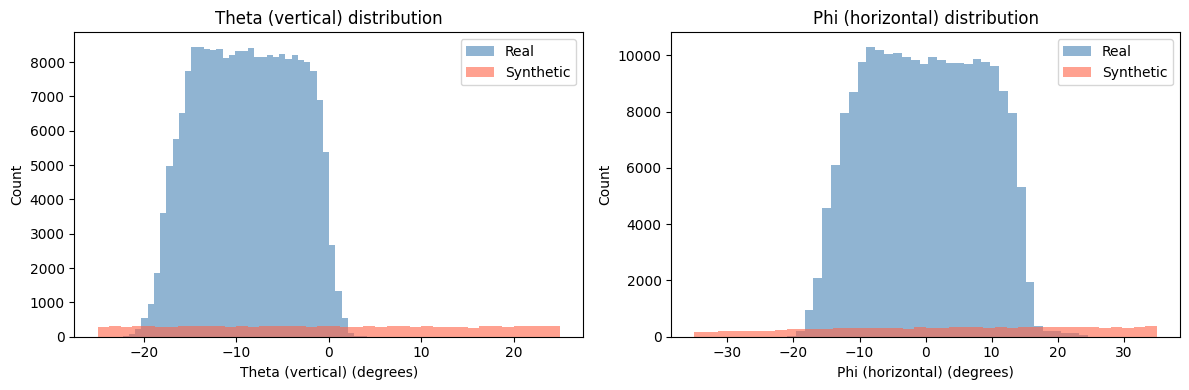

In [31]:
import glob

def rebase_path(old_path: str, new_root: str) -> str:
    """Replace the directory component with new_root. Handles Windows backslash paths."""
    fname = old_path.replace('\\', '/').split('/')[-1]
    return os.path.join(new_root, fname)

# Actual image subdirectories inside extraction roots (zip preserves folder name)
IMAGES_MPII  = f'{EXTRACT_MPII}/mpii'       # /content/crops/mpii/mpii/
IMAGES_UNITY = f'{EXTRACT_UNITY}/unity_gs'  # /content/crops/unity/unity_gs/

# Build sets of filenames actually present on disk (fast lookup)
mpii_on_disk  = {os.path.basename(p) for p in glob.glob(f'{IMAGES_MPII}/*.jpg')}
unity_on_disk = {os.path.basename(p) for p in glob.glob(f'{IMAGES_UNITY}/*.jpg')}
print(f"MPII  images on disk : {len(mpii_on_disk):>6}")
print(f"Unity images on disk : {len(unity_on_disk):>6}")

# ── Load ALL real data (no cap here — cap is applied to training only after split) ──
df_real = pd.read_csv(MPII_CSV)
df_real = df_real[df_real['side'] == 'right'].copy()
df_real['_fname'] = df_real['filepath'].apply(lambda p: p.replace('\\', '/').split('/')[-1])
df_real = df_real[df_real['_fname'].isin(mpii_on_disk)].drop(columns='_fname')
df_real = df_real.sample(frac=1, random_state=SEED).reset_index(drop=True)   # shuffle only
df_real['filepath'] = df_real['filepath'].apply(lambda p: rebase_path(p, IMAGES_MPII))

# ── Extract participant ID for person-level splitting ─────────────────────────
# Priority: use an existing CSV column if available, otherwise parse the filename.
_PARTICIPANT_COLS = ['participant', 'subject', 'person', 'person_id', 'participant_id', 'subject_id']
_found_col = next((c for c in _PARTICIPANT_COLS if c in df_real.columns), None)

if _found_col:
    df_real['subject'] = df_real[_found_col].astype(str)
    print(f"Using CSV column '{_found_col}' as participant ID.")
else:
    # Fallback: parse filename. MPIIGaze normalised filenames are pXX_NNNNN.jpg.
    # If that yields only one unique value the filenames don't carry participant info
    # and we assign IDs by splitting the full pool into 15 equal-sized groups.
    _parsed = df_real['filepath'].apply(lambda p: os.path.basename(p).split('_')[0])
    if _parsed.nunique() > 1:
        df_real['subject'] = _parsed
        print(f"Participant ID parsed from filename prefix.")
    else:
        # Assign 15 pseudo-participant groups so the person-level split still works
        N_PSEUDO = 15
        _ids = np.array_split(np.arange(len(df_real)), N_PSEUDO)
        _label_arr = np.empty(len(df_real), dtype=object)
        for i, idx in enumerate(_ids):
            _label_arr[idx] = f'p{i:02d}'
        df_real['subject'] = _label_arr
        print(f"⚠  No participant column found and filename prefix is not unique.")
        print(f"   Assigned {N_PSEUDO} pseudo-participant groups for person-level split.")
        print(f"   For a truly identity-leak-free split, add a 'participant' column to {MPII_CSV}.")

print(f"\nReal data (all): {len(df_real)} samples  |  "
      f"Participants (n={df_real['subject'].nunique()}): {sorted(df_real['subject'].unique())}")
print(f"(MAX_REAL cap of {MAX_REAL} applied to training portion only after split)")

# ── Load synthetic (UnityEyes2, files-on-disk filtered) ──────────────────────
df_synth = pd.read_csv(UNITY_CSV)
df_synth['_fname'] = df_synth['filepath'].apply(lambda p: p.replace('\\', '/').split('/')[-1])
df_synth = df_synth[df_synth['_fname'].isin(unity_on_disk)].drop(columns='_fname')
df_synth = df_synth.sample(n=min(MAX_SYNTH, len(df_synth)), random_state=SEED).reset_index(drop=True)
df_synth['filepath'] = df_synth['filepath'].apply(lambda p: rebase_path(p, IMAGES_UNITY))

print(f"Synthetic: {len(df_synth)} samples")

# ── Distribution plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ['theta', 'phi'], ['Theta (vertical)', 'Phi (horizontal)']):
    ax.hist(np.degrees(df_real[col]),  bins=40, alpha=0.6, label='Real',      color='steelblue')
    ax.hist(np.degrees(df_synth[col]), bins=40, alpha=0.6, label='Synthetic', color='tomato')
    ax.set_xlabel(f'{label} (degrees)'); ax.set_ylabel('Count')
    ax.set_title(f'{label} distribution'); ax.legend()
plt.tight_layout(); plt.show()


## 4. Dataset Class & Subject-Level Train/Val/Test Split
**Subject-level split** to eliminate subject identity leakage: MPIIGaze subjects are assigned to splits at the subject level so the test set contains entirely held-out identities the model has never seen.  
- **Train**: 11 subjects + all 12 K synthetic (no real identities in synthetic)  
- **Val**: 2 subjects, real only  
- **Test**: 2 subjects, real only  

Augmentation applied only to the training split.

In [32]:
class GazeDataset(Dataset):
    """Eye-crop dataset returning (image_tensor, [theta_n, phi_n])."""

    # Augmentation for training split
    TRAIN_TF = T.Compose([
        T.RandomHorizontalFlip(p=0.0),   # NO horizontal flip — flipping changes phi sign
        T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
        T.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.95, 1.05)),
        T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225]),
    ])

    EVAL_TF = T.Compose([
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406],
                    std =[0.229, 0.224, 0.225]),
    ])

    def __init__(self, df: pd.DataFrame, augment: bool = False):
        self.df      = df.reset_index(drop=True)
        self.augment = augment
        self.tf      = self.TRAIN_TF if augment else self.EVAL_TF

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['filepath']).convert('RGB').resize((CROP_SIZE, CROP_SIZE))
        img = self.tf(img)

        # Normalise labels to [-1, 1]
        theta_n = float(row['theta']) / THETA_MAX
        phi_n   = float(row['phi'])   / PHI_MAX
        label   = torch.tensor([theta_n, phi_n], dtype=torch.float32)
        return img, label


# ── Subject-level split — eliminates subject identity leakage ────────────────
# Shuffle subjects with fixed seed, then assign to splits
_subjects      = sorted(df_real['subject'].unique())
_subjects_shuf = np.random.RandomState(SEED).permutation(_subjects).tolist()
_n             = len(_subjects_shuf)
_n_test        = max(1, round(_n * 0.15))   # ~2 subjects
_n_val         = max(1, round(_n * 0.15))   # ~2 subjects

TEST_SUBJECTS  = _subjects_shuf[:_n_test]
VAL_SUBJECTS   = _subjects_shuf[_n_test : _n_test + _n_val]
TRAIN_SUBJECTS = _subjects_shuf[_n_test + _n_val:]

print(f"Train subjects ({len(TRAIN_SUBJECTS)}): {TRAIN_SUBJECTS}")
print(f"Val   subjects ({len(VAL_SUBJECTS)}):   {VAL_SUBJECTS}")
print(f"Test  subjects ({len(TEST_SUBJECTS)}):  {TEST_SUBJECTS}")

_real_train_all = df_real[df_real['subject'].isin(TRAIN_SUBJECTS)].copy()
_real_val       = df_real[df_real['subject'].isin(VAL_SUBJECTS)].copy()
_real_test      = df_real[df_real['subject'].isin(TEST_SUBJECTS)].copy()

# Cap real training and val data — test uses ALL its images (runs once, most honest)
_real_train = _real_train_all.sample(n=min(MAX_REAL, len(_real_train_all)), random_state=SEED)
_real_val   = _real_val.sample(n=min(MAX_VAL, len(_real_val)), random_state=SEED)

print(f"\nReal train pool : {len(_real_train_all)} available → using {len(_real_train)} (capped at MAX_REAL={MAX_REAL})")
print(f"Real val        : {len(_real_val)} (capped at MAX_VAL={MAX_VAL}, from val participants)")
print(f"Real test       : {len(_real_test)} (all images from test participants — no cap, runs once)")

# All synthetic goes to training — no real identities to leak
train_df = pd.concat([_real_train, df_synth]).sample(frac=1, random_state=SEED).reset_index(drop=True)
val_df   = _real_val.reset_index(drop=True)
test_df  = _real_test.reset_index(drop=True)

train_ds = GazeDataset(train_df, augment=True)
val_ds   = GazeDataset(val_df,   augment=False)
test_ds  = GazeDataset(test_df,  augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"\nTrain : {len(train_ds):>6}  ({len(_real_train)} real + {len(df_synth)} synth)")
print(f"Val   : {len(val_ds):>6}  (real only — held-out subjects)")
print(f"Test  : {len(test_ds):>6}  (real only — held-out subjects, full data)")


Train subjects (11): ['p05', 'p08', 'p02', 'p01', 'p14', 'p04', 'p07', 'p10', 'p12', 'p03', 'p06']
Val   subjects (2):   ['p00', 'p13']
Test  subjects (2):  ['p09', 'p11']

Real train pool : 171217 available → using 12000 (capped at MAX_REAL=12000)
Real val        : 3000 (capped at MAX_VAL=3000, from val participants)
Real test       : 10977 (all images from test participants — no cap, runs once)

Train :  24000  (12000 real + 12000 synth)
Val   :   3000  (real only — held-out subjects)
Test  :  10977  (real only — held-out subjects, full data)


## 5. Model — EfficientNet-B0
Pretrained backbone, head replaced with a two-output regression head → `Tanh()` → [−1, 1].

In [33]:
def build_model() -> nn.Module:
    model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0)
    in_features = model.num_features          # 1280 for B0
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.2),
        nn.Linear(256, 2),
        nn.Tanh()                             # output ∈ [-1, 1]
    )
    return model


model = build_model().to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

criterion = nn.HuberLoss(delta=HUBER_DELTA)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

Total params    : 4,335,998
Trainable params: 4,335,998


## 5b. Training Time Estimate
Runs 20 batches through a forward + backward pass and extrapolates. **Run this before committing to full training** — if one epoch is too slow, reduce `MAX_REAL`, `MAX_SYNTH`, or `BATCH_SIZE` above and re-run cell 3 & 4.

In [ ]:
import time

BENCHMARK_BATCHES = 20   # how many batches to time

# Use a temporary model so the benchmark does not modify the real training state.
benchmark_model = build_model().to(DEVICE)
benchmark_model.load_state_dict(model.state_dict())
benchmark_model.train()
_opt = torch.optim.SGD(benchmark_model.parameters(), lr=1e-3)  # throwaway — just for backward pass

times = []
for i, (imgs, labels) in enumerate(train_loader):
    if i >= BENCHMARK_BATCHES:
        break
    t0 = time.perf_counter()
    imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
    loss = criterion(benchmark_model(imgs), labels)
    _opt.zero_grad(); loss.backward(); _opt.step()
    if DEVICE.type == 'cuda':
        torch.cuda.synchronize()
    times.append(time.perf_counter() - t0)

del benchmark_model, _opt
model.eval()

avg_batch_s  = sum(times) / len(times)
batches_per_epoch = math.ceil(len(train_ds) / BATCH_SIZE)
epoch_s      = avg_batch_s * batches_per_epoch
full_train_s = epoch_s * EPOCHS   # worst case (no early stopping)
n_ratio_runs = 3  # matches the three fractions in the ratio experiment cell

print(f"Batch size          : {BATCH_SIZE}")
print(f"Batches per epoch   : {batches_per_epoch}")
print(f"Avg time / batch    : {avg_batch_s*1000:.1f} ms")
print()
print(f"Est. time / epoch   : {epoch_s:.0f}s  ({epoch_s/60:.1f} min)")
print(f"Est. full {EPOCHS} epochs : {full_train_s/60:.0f} min  ({full_train_s/3600:.1f} hr)")
print()

# ── Recommendations ───────────────────────────────────────────────────────────
if epoch_s > 300:
    rec_samples = int((len(train_ds) / epoch_s) * 120)   # target 2-min epochs
    print(f"⚠  Epoch > 5 min. Consider reducing MAX_REAL/MAX_SYNTH.")
    print(f"   For ~2 min epochs, use ~{rec_samples:,} total training samples.")
elif epoch_s > 120:
    print(f"⚠  Epoch ~{epoch_s/60:.1f} min. Manageable, but ratio experiment (×{n_ratio_runs}) will take ~{epoch_s/60*RATIO_EPOCHS*n_ratio_runs/60:.1f} hr.")
else:
    print(f"✓  Epoch time looks good. Full training + ratio experiment should complete in ~{(full_train_s + epoch_s*RATIO_EPOCHS*n_ratio_runs)/3600:.1f} hr.")


Batch size          : 64
Batches per epoch   : 263
Avg time / batch    : 127.6 ms

Est. time / epoch   : 34s  (0.6 min)
Est. full 30 epochs : 17 min  (0.3 hr)

✓  Epoch time looks good. Full training + ratio experiment should complete in ~1.4 hr.


## 6. Training Loop
Trains with early stopping on validation loss. Saves the best checkpoint to Drive.

Ep   1/25  train=0.0110  val=0.0058  lr=2.99e-04  ✓ saved  (97.4s)
Ep   2/25  train=0.0058  val=0.0042  lr=2.95e-04  ✓ saved  (98.1s)
Ep   3/25  train=0.0047  val=0.0041  lr=2.90e-04  ✓ saved  (97.4s)
Ep   4/25  train=0.0042  val=0.0034  lr=2.82e-04  ✓ saved  (95.2s)
Ep   5/25  train=0.0038  val=0.0036  lr=2.71e-04  patience 1/50  (96.0s)
Ep   6/25  train=0.0034  val=0.0033  lr=2.59e-04  ✓ saved  (94.1s)
Ep   7/25  train=0.0031  val=0.0050  lr=2.46e-04  patience 1/50  (96.6s)
Ep   8/25  train=0.0029  val=0.0031  lr=2.31e-04  ✓ saved  (95.6s)
Ep   9/25  train=0.0027  val=0.0031  lr=2.14e-04  patience 1/50  (96.6s)
Ep  10/25  train=0.0025  val=0.0025  lr=1.97e-04  ✓ saved  (96.9s)
Ep  11/25  train=0.0024  val=0.0037  lr=1.79e-04  patience 1/50  (97.0s)
Ep  12/25  train=0.0022  val=0.0031  lr=1.60e-04  patience 2/50  (97.8s)
Ep  13/25  train=0.0020  val=0.0039  lr=1.41e-04  patience 3/50  (95.3s)
Ep  14/25  train=0.0020  val=0.0029  lr=1.22e-04  patience 4/50  (95.7s)
Ep  15/25  train=0.0

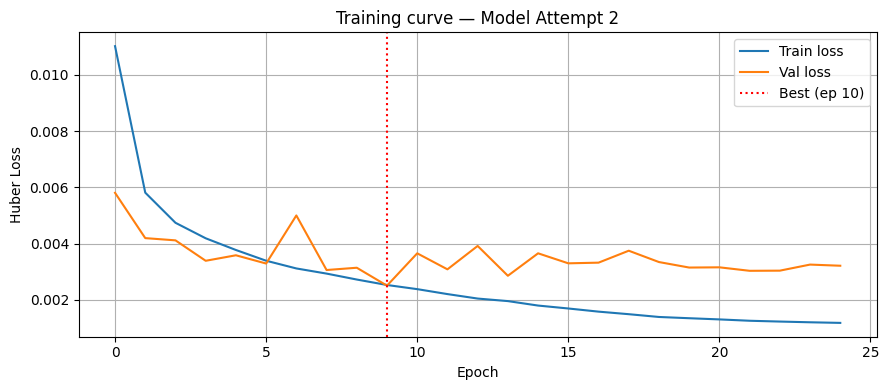


Best val loss : 0.00250  (epoch 10)
Checkpoint saved to: /content/drive/MyDrive/FYP_3DML/gaze_model_attempt2_best.pth


In [34]:
CKPT_PATH = f'{DRIVE_ROOT}/gaze_model_attempt2_best.pth'

def run_epoch(loader, model, criterion, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, n = 0.0, 0
    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            preds = model(imgs)
            loss  = criterion(preds, labels)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(imgs)
            n          += len(imgs)
    return total_loss / n


# ── Training ─────────────────────────────────────────────────────────────────
history = {'train': [], 'val': []}
best_val, best_epoch, patience_counter = float('inf'), 0, 0

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    tr_loss  = run_epoch(train_loader, model, criterion, optimizer)
    val_loss = run_epoch(val_loader,   model, criterion)
    scheduler.step()

    history['train'].append(tr_loss)
    history['val'].append(val_loss)

    improved = val_loss < best_val
    if improved:
        best_val = val_loss
        best_epoch = epoch
        patience_counter = 0
        torch.save(model.state_dict(), CKPT_PATH)
        tag = '✓ saved'
    else:
        patience_counter += 1
        tag = f'patience {patience_counter}/{PATIENCE}'

    print(f"Ep {epoch:3d}/{EPOCHS}  "
          f"train={tr_loss:.4f}  val={val_loss:.4f}  "
          f"lr={scheduler.get_last_lr()[0]:.2e}  "
          f"{tag}  ({time.time()-t0:.1f}s)")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

# ── Loss curve ────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 4))
plt.plot(history['train'], label='Train loss')
plt.plot(history['val'],   label='Val loss')
plt.axvline(best_epoch - 1, color='red', linestyle=':', linewidth=1.5, label=f'Best (ep {best_epoch})')
plt.xlabel('Epoch'); plt.ylabel('Huber Loss')
plt.title('Training curve — Model Attempt 2'); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

print(f"\nBest val loss : {best_val:.5f}  (epoch {best_epoch})")
print(f"Checkpoint saved to: {CKPT_PATH}")


## 7. Evaluation — Core Metrics
Load the best checkpoint and evaluate on the held-out test set.  
Reports **MAE°**, **RMSE°**, **R²** for theta (vertical) and phi (horizontal) separately, plus combined angular error.

────────────────────────────────────────────────────
Test set metrics (best model)
────────────────────────────────────────────────────
  Theta   MAE=3.656°  RMSE=4.415°  R²=0.2188
  Phi     MAE=3.370°  RMSE=4.257°  R²=0.7312
  Angular combined  MAE=5.443°  RMSE=6.133°
────────────────────────────────────────────────────


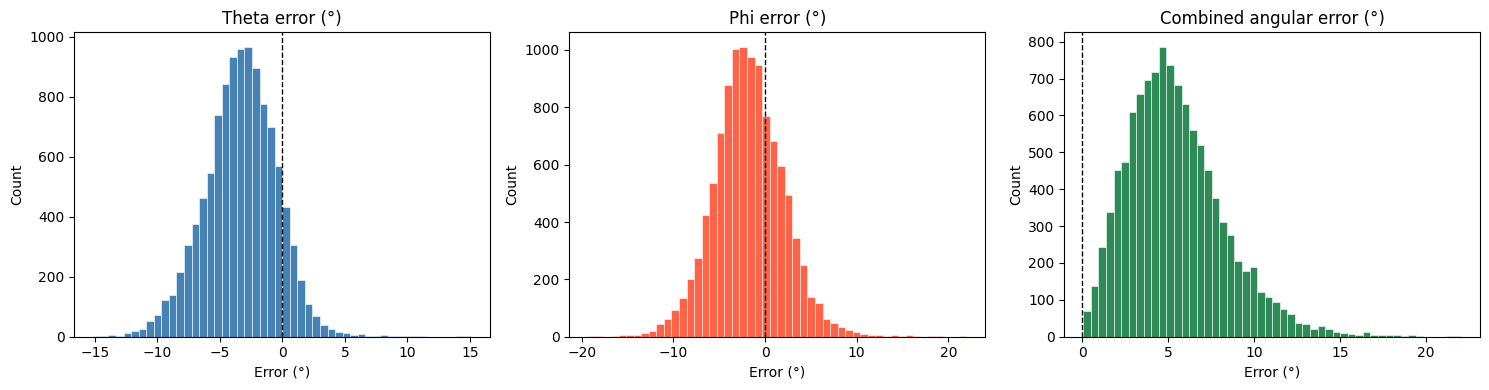

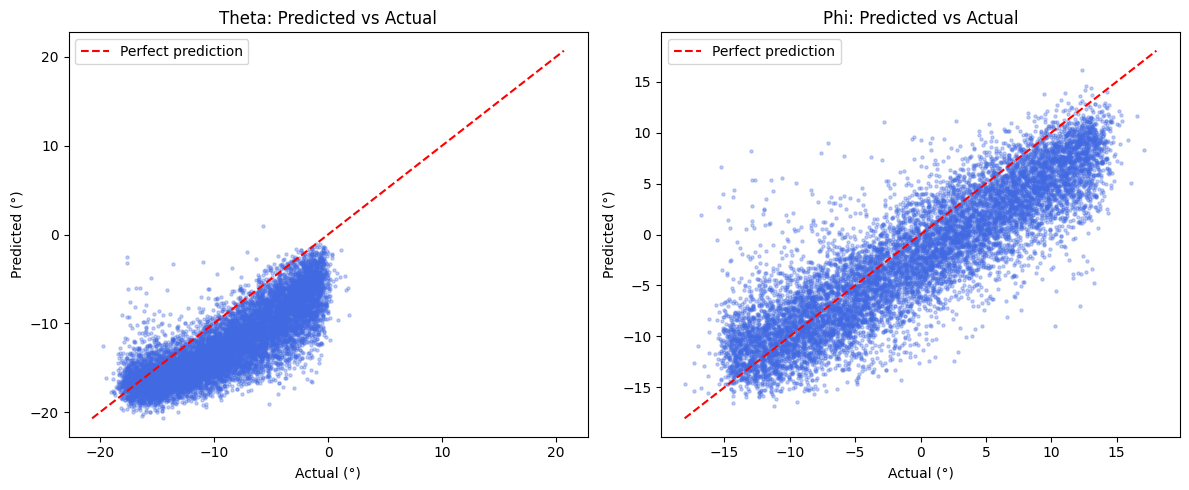

In [35]:
from sklearn.metrics import r2_score

# ── Load best weights ─────────────────────────────────────────────────────────
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

# ── Collect predictions ───────────────────────────────────────────────────────
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        preds = model(imgs.to(DEVICE)).cpu()
        all_preds.append(preds); all_labels.append(labels)

preds_n  = torch.cat(all_preds).numpy()    # normalised [-1, 1]
labels_n = torch.cat(all_labels).numpy()

# De-normalise to radians then degrees
preds_deg  = preds_n  * np.array([math.degrees(THETA_MAX), math.degrees(PHI_MAX)])
labels_deg = labels_n * np.array([math.degrees(THETA_MAX), math.degrees(PHI_MAX)])

theta_err = preds_deg[:, 0] - labels_deg[:, 0]
phi_err   = preds_deg[:, 1] - labels_deg[:, 1]

# Combined angular error (geodesic approximation for small angles)
angular_err = np.sqrt(theta_err**2 + phi_err**2)

def metrics(err, axis_name):
    mae  = np.abs(err).mean()
    rmse = np.sqrt((err**2).mean())
    # R² on predictions vs labels
    r2   = r2_score(labels_deg[:, 0 if axis_name == 'Theta' else 1],
                    preds_deg[:,  0 if axis_name == 'Theta' else 1])
    print(f"  {axis_name:6s}  MAE={mae:.3f}°  RMSE={rmse:.3f}°  R²={r2:.4f}")
    return mae, rmse, r2

print("─" * 52)
print("Test set metrics (best model)")
print("─" * 52)
t_mae, t_rmse, t_r2 = metrics(theta_err, 'Theta')
p_mae, p_rmse, p_r2 = metrics(phi_err,   'Phi')
print(f"  Angular combined  MAE={angular_err.mean():.3f}°  RMSE={np.sqrt((angular_err**2).mean()):.3f}°")
print("─" * 52)

# ── Error distribution plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, err, title, color in zip(
    axes,
    [theta_err, phi_err, angular_err],
    ['Theta error (°)', 'Phi error (°)', 'Combined angular error (°)'],
    ['steelblue', 'tomato', 'seagreen']
):
    ax.hist(err, bins=50, color=color, edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=1, linestyle='--')
    ax.set_title(title); ax.set_xlabel('Error (°)'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

# ── Scatter: predicted vs actual ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, true, title in zip(
    axes,
    [preds_deg[:, 0], preds_deg[:, 1]],
    [labels_deg[:, 0], labels_deg[:, 1]],
    ['Theta: Predicted vs Actual', 'Phi: Predicted vs Actual']
):
    ax.scatter(true, pred, alpha=0.3, s=5, color='royalblue')
    lim = max(abs(np.array([true, pred]).flatten()).max(), 1)
    ax.plot([-lim, lim], [-lim, lim], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual (°)'); ax.set_ylabel('Predicted (°)')
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

## 7b. Extended Gaze-Specific Metrics
Threshold accuracy, pixel error on screen, median error, 95th percentile, and per-quadrant breakdown.

────────────────────────────────────────────────────
Threshold accuracy (angular error)
────────────────────────────────────────────────────
  Within  2°  : 9.0%
  Within  5°  : 48.9%
  Within 10°  : 93.3%

────────────────────────────────────────────────────
Robust statistics
────────────────────────────────────────────────────
  Median angular error : 5.065°
  95th percentile      : 10.651°
  Median theta error   : 3.353°
  Median phi error     : 2.854°

────────────────────────────────────────────────────
Pixel error on 1920×1080 display @ 600 mm
────────────────────────────────────────────────────
  Theta  MAE  : 238.5 px
  Phi    MAE  : 220.2 px
  Combined MAE: 355.4 px
  Combined 95p: 698.2 px

────────────────────────────────────────────────────
Angular MAE by screen quadrant (gaze direction)
────────────────────────────────────────────────────
  Top-Left    (θ<0, φ<0): 4.730°  (n=5603)
  Top-Right   (θ<0, φ>0): 6.177°  (n=5339)
  Bottom-Left (θ>0, φ<0): 6.610°  (n=18)
  Bottom-

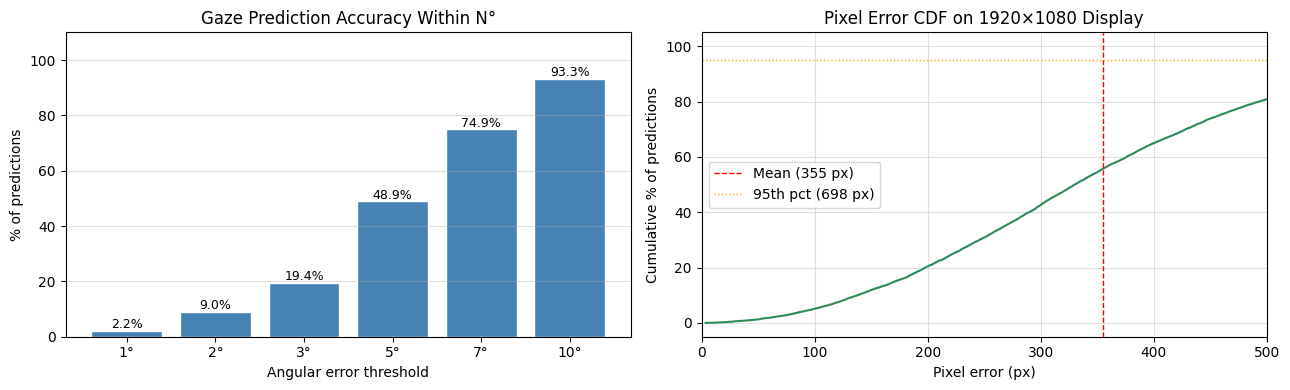

In [36]:
# ── 1. Threshold accuracy — % of predictions within N degrees ────────────────
print("─" * 52)
print("Threshold accuracy (angular error)")
print("─" * 52)
for thresh in [2, 5, 10]:
    pct = (angular_err < thresh).mean() * 100
    print(f"  Within {thresh:2d}°  : {pct:.1f}%")
print()

# ── 2. Median & 95th percentile ───────────────────────────────────────────────
print("─" * 52)
print("Robust statistics")
print("─" * 52)
print(f"  Median angular error : {np.median(angular_err):.3f}°")
print(f"  95th percentile      : {np.percentile(angular_err, 95):.3f}°")
print(f"  Median theta error   : {np.median(np.abs(theta_err)):.3f}°")
print(f"  Median phi error     : {np.median(np.abs(phi_err)):.3f}°")
print()

# ── 3. Pixel error on screen ──────────────────────────────────────────────────
# Assumes 1920×1080 display, 309×174 mm physical, 600 mm viewing distance
SCREEN_PX_W  = 1920
SCREEN_PX_H  = 1080
SCREEN_MM_W  = 309.0
SCREEN_MM_H  = 174.0
DIST_MM_EVAL = 600.0

px_per_mm_w = SCREEN_PX_W / SCREEN_MM_W
px_per_mm_h = SCREEN_PX_H / SCREEN_MM_H

# Convert angular error to mm displacement at viewing distance, then to pixels
theta_mm  = np.tan(np.radians(np.abs(theta_err))) * DIST_MM_EVAL
phi_mm    = np.tan(np.radians(np.abs(phi_err)))   * DIST_MM_EVAL
theta_px  = theta_mm * px_per_mm_h
phi_px    = phi_mm   * px_per_mm_w
combined_px = np.sqrt(theta_px**2 + phi_px**2)

print("─" * 52)
print("Pixel error on 1920×1080 display @ 600 mm")
print("─" * 52)
print(f"  Theta  MAE  : {theta_px.mean():.1f} px")
print(f"  Phi    MAE  : {phi_px.mean():.1f} px")
print(f"  Combined MAE: {combined_px.mean():.1f} px")
print(f"  Combined 95p: {np.percentile(combined_px, 95):.1f} px")
print()

# ── 4. Per-quadrant angular error ─────────────────────────────────────────────
print("─" * 52)
print("Angular MAE by screen quadrant (gaze direction)")
print("─" * 52)
quadrants = {
    'Top-Left    (θ<0, φ<0)': (labels_deg[:, 0] < 0) & (labels_deg[:, 1] < 0),
    'Top-Right   (θ<0, φ>0)': (labels_deg[:, 0] < 0) & (labels_deg[:, 1] > 0),
    'Bottom-Left (θ>0, φ<0)': (labels_deg[:, 0] > 0) & (labels_deg[:, 1] < 0),
    'Bottom-Right(θ>0, φ>0)': (labels_deg[:, 0] > 0) & (labels_deg[:, 1] > 0),
}
for name, mask in quadrants.items():
    if mask.sum() > 0:
        q_mae = angular_err[mask].mean()
        print(f"  {name}: {q_mae:.3f}°  (n={mask.sum()})")

# ── 5. Threshold accuracy bar chart ──────────────────────────────────────────
thresholds = [1, 2, 3, 5, 7, 10]
pcts = [(angular_err < t).mean() * 100 for t in thresholds]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar([f"{t}°" for t in thresholds], pcts, color='steelblue', edgecolor='white')
for i, (t, p) in enumerate(zip(thresholds, pcts)):
    axes[0].text(i, p + 1, f"{p:.1f}%", ha='center', fontsize=9)
axes[0].set_ylim(0, 110)
axes[0].set_xlabel('Angular error threshold')
axes[0].set_ylabel('% of predictions')
axes[0].set_title('Gaze Prediction Accuracy Within N°')
axes[0].grid(axis='y', alpha=0.4)

# Pixel error CDF
sorted_px = np.sort(combined_px)
cdf = np.arange(1, len(sorted_px) + 1) / len(sorted_px) * 100
axes[1].plot(sorted_px, cdf, color='seagreen', linewidth=1.5)
axes[1].axvline(combined_px.mean(), color='red', linestyle='--', linewidth=1,
                label=f'Mean ({combined_px.mean():.0f} px)')
axes[1].axhline(95, color='orange', linestyle=':', linewidth=1,
                label=f'95th pct ({np.percentile(combined_px, 95):.0f} px)')
axes[1].set_xlabel('Pixel error (px)')
axes[1].set_ylabel('Cumulative % of predictions')
axes[1].set_title('Pixel Error CDF on 1920×1080 Display')
axes[1].legend(); axes[1].grid(alpha=0.4)
axes[1].set_xlim(0, min(np.percentile(combined_px, 99) * 1.1, 500))

plt.tight_layout(); plt.show()


## 8. Sectional Accuracy — 4 × 3 Imaginary Display Grid
Maps gaze angles to a 1920 × 1080 display at 600 mm viewing distance, divides it into a 4-column × 3-row grid (12 zones), and computes per-zone classification accuracy.  
This mirrors the confusion-matrix test described in the thesis (Chapter 8).

Overall zone accuracy (4×3 grid): 51.44%

  Zone R1C1 : 79.7%  (n=2467)
  Zone R1C2 : 62.7%  (n=2342)
  Zone R1C3 : 56.2%  (n=2465)
  Zone R1C4 : 36.1%  (n=2183)
  Zone R2C1 : 2.9%  (n=407)
  Zone R2C2 : 4.9%  (n=405)
  Zone R2C3 : 1.7%  (n=360)
  Zone R2C4 : 0.0%  (n=348)
  Zone R3C1 : nan%  (n=0)
  Zone R3C2 : nan%  (n=0)
  Zone R3C3 : nan%  (n=0)
  Zone R3C4 : nan%  (n=0)


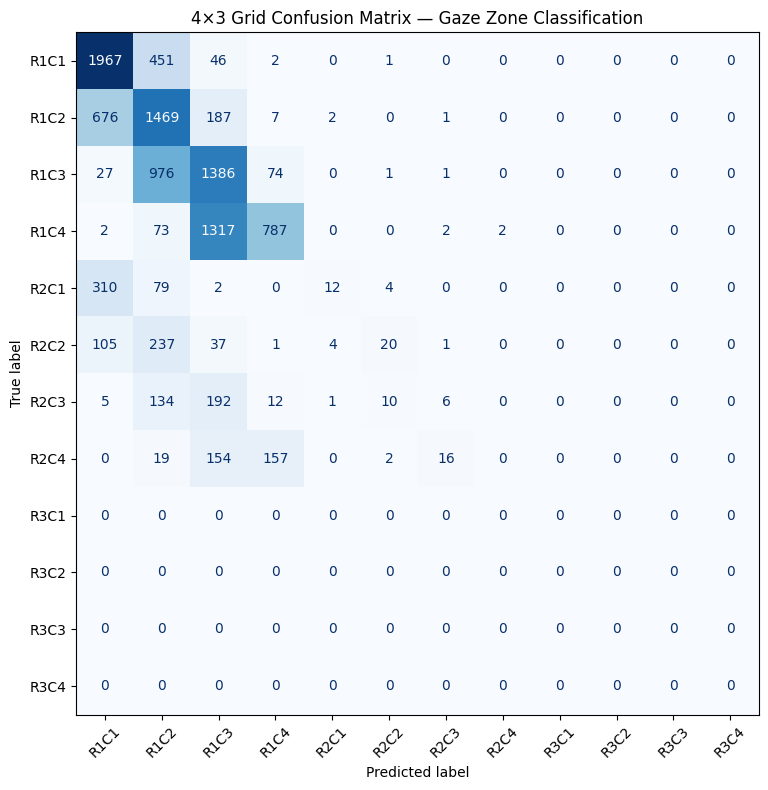

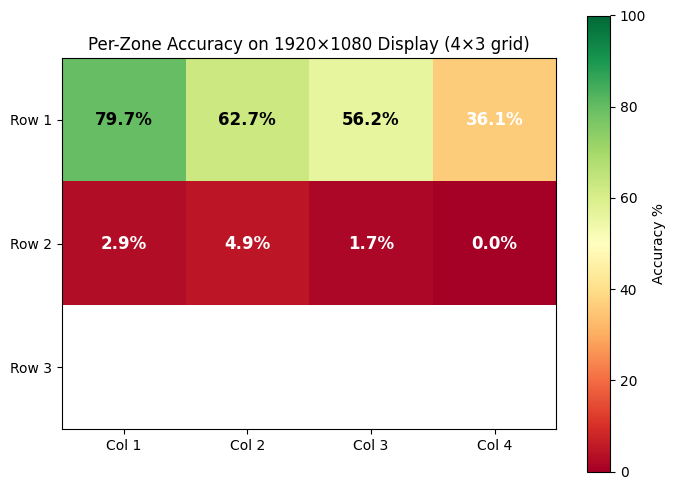

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ── Display geometry ──────────────────────────────────────────────────────────
SCREEN_W_MM   = 309.0    # 14" display physical width  (mm)
SCREEN_H_MM   = 174.0    # 14" display physical height (mm)
DIST_MM       = 600.0    # viewing distance (mm)
GRID_COLS     = 4
GRID_ROWS     = 3
N_ZONES       = GRID_COLS * GRID_ROWS   # 12

# Half-angles of the screen edges (radians)
PHI_EDGE   = math.atan2(SCREEN_W_MM / 2, DIST_MM)    # ±14.4°
THETA_EDGE = math.atan2(SCREEN_H_MM / 2, DIST_MM)    # ±8.3°

# Zone boundaries (evenly spaced)
phi_bins   = np.linspace(-PHI_EDGE,   PHI_EDGE,   GRID_COLS + 1)
theta_bins = np.linspace(-THETA_EDGE, THETA_EDGE, GRID_ROWS + 1)

def angle_to_zone(theta_rad: np.ndarray, phi_rad: np.ndarray) -> np.ndarray:
    """Map gaze angles to zone index 0-11 (row-major). Returns -1 if off-screen."""
    col = np.digitize(phi_rad,   phi_bins)   - 1   # 0..3
    row = np.digitize(theta_rad, theta_bins) - 1   # 0..2
    col = np.clip(col, 0, GRID_COLS - 1)
    row = np.clip(row, 0, GRID_ROWS - 1)
    return row * GRID_COLS + col

# Convert degrees → radians for zone mapping
true_zones  = angle_to_zone(np.radians(labels_deg[:, 0]), np.radians(labels_deg[:, 1]))
pred_zones  = angle_to_zone(np.radians(preds_deg[:,  0]), np.radians(preds_deg[:,  1]))

# ── Zone accuracy ─────────────────────────────────────────────────────────────
overall_acc = (true_zones == pred_zones).mean() * 100
print(f"Overall zone accuracy (4×3 grid): {overall_acc:.2f}%\n")

zone_labels = [f"R{r+1}C{c+1}" for r in range(GRID_ROWS) for c in range(GRID_COLS)]
per_zone_acc = []
for z in range(N_ZONES):
    mask = true_zones == z
    if mask.sum() == 0:
        per_zone_acc.append(float('nan'))
    else:
        per_zone_acc.append((pred_zones[mask] == z).mean() * 100)
    print(f"  Zone {zone_labels[z]:5s}: {per_zone_acc[-1]:.1f}%  (n={mask.sum()})")

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(true_zones, pred_zones, labels=list(range(N_ZONES)))
fig, ax = plt.subplots(figsize=(11, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=zone_labels)
disp.plot(ax=ax, cmap='Blues', colorbar=False, xticks_rotation=45)
ax.set_title('4×3 Grid Confusion Matrix — Gaze Zone Classification')
plt.tight_layout(); plt.show()

# ── Heatmap of per-zone accuracy on display layout ───────────────────────────
acc_grid = np.array(per_zone_acc).reshape(GRID_ROWS, GRID_COLS)
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(acc_grid, cmap='RdYlGn', vmin=0, vmax=100)
for r in range(GRID_ROWS):
    for c in range(GRID_COLS):
        ax.text(c, r, f"{acc_grid[r, c]:.1f}%", ha='center', va='center',
                fontsize=12, fontweight='bold',
                color='black' if acc_grid[r, c] > 40 else 'white')
ax.set_xticks(range(GRID_COLS)); ax.set_xticklabels([f'Col {c+1}' for c in range(GRID_COLS)])
ax.set_yticks(range(GRID_ROWS)); ax.set_yticklabels([f'Row {r+1}' for r in range(GRID_ROWS)])
ax.set_title('Per-Zone Accuracy on 1920×1080 Display (4×3 grid)')
plt.colorbar(im, ax=ax, label='Accuracy %')
plt.tight_layout(); plt.show()

## 9. Synthetic-to-Real Ratio Experiment
Trains 6 models on the **same fixed test set**, sweeping the synthetic fraction of training data from 0 % (all real) to 100 % (all synthetic).  
Total training samples = 16 800 (70 % of 24 K) in each run.  
Reports test MAE° and zone accuracy for each ratio — answers "how much synthetic data is optimal?"

In [ ]:
SYNTH_FRACTIONS = [0.3, 0.5, 0.7]   # 30% synth/70% real, 50/50, 70% synth/30% real

# Keep test set fixed — same held-out subjects as main evaluation
ratio_test_loader = DataLoader(
    GazeDataset(test_df, augment=False),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True
)

# Real pool for ratio experiment: only non-test subjects (same as main training pool)
_ratio_real_pool = df_real[df_real['subject'].isin(TRAIN_SUBJECTS + VAL_SUBJECTS)].copy()
print(f"Ratio experiment real pool: {len(_ratio_real_pool)} samples "
      f"(subjects: {sorted(_ratio_real_pool['subject'].unique())})")

def evaluate_model(model, loader):
    """Returns (mae_theta_deg, mae_phi_deg, angular_mae_deg, zone_acc_pct)."""
    model.eval()
    all_p, all_l = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            all_p.append(model(imgs.to(DEVICE)).cpu())
            all_l.append(labels)
    p = torch.cat(all_p).numpy()
    l = torch.cat(all_l).numpy()
    p_deg = p * np.array([math.degrees(THETA_MAX), math.degrees(PHI_MAX)])
    l_deg = l * np.array([math.degrees(THETA_MAX), math.degrees(PHI_MAX)])
    mae_t = np.abs(p_deg[:, 0] - l_deg[:, 0]).mean()
    mae_p = np.abs(p_deg[:, 1] - l_deg[:, 1]).mean()
    ang   = np.sqrt((p_deg[:, 0]-l_deg[:, 0])**2 + (p_deg[:, 1]-l_deg[:, 1])**2).mean()
    tz    = angle_to_zone(np.radians(l_deg[:, 0]), np.radians(l_deg[:, 1]))
    pz    = angle_to_zone(np.radians(p_deg[:, 0]), np.radians(p_deg[:, 1]))
    zacc  = (tz == pz).mean() * 100
    return mae_t, mae_p, ang, zacc


ratio_results = []

for synth_frac in SYNTH_FRACTIONS:
    print(f"\n{'='*55}")
    print(f"Ratio: {synth_frac*100:.0f}% synthetic / {(1-synth_frac)*100:.0f}% real")
    print(f"{'='*55}")

    # Build training dataframe for this ratio
    n_train_total = len(train_df)
    n_synth = int(n_train_total * synth_frac)
    n_real  = n_train_total - n_synth

    # Sample from non-test-subject pools only
    real_pool  = _ratio_real_pool.sample(n=min(n_real,  len(_ratio_real_pool)),  random_state=SEED)
    synth_pool = df_synth.sample(n=min(n_synth, len(df_synth)), random_state=SEED)
    ratio_train_df = pd.concat([real_pool, synth_pool]).sample(frac=1, random_state=SEED)

    # Val set: real only from remaining non-test-subject pool
    n_val_total = len(val_df)
    n_val_synth = int(n_val_total * synth_frac)
    n_val_real  = n_val_total - n_val_synth
    real_val_pool  = _ratio_real_pool.drop(real_pool.index, errors='ignore').sample(
        n=min(n_val_real,  max(len(_ratio_real_pool) - len(real_pool), 0)), random_state=SEED+1)
    synth_val_pool = df_synth.drop(synth_pool.index, errors='ignore').sample(
        n=min(n_val_synth, max(len(df_synth) - len(synth_pool), 0)), random_state=SEED+1)
    ratio_val_df = pd.concat([real_val_pool, synth_val_pool]).sample(frac=1, random_state=SEED)

    r_train_loader = DataLoader(GazeDataset(ratio_train_df, augment=True),
                                batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    r_val_loader   = DataLoader(GazeDataset(ratio_val_df,   augment=False),
                                batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

    # Fresh model each time
    r_model = build_model().to(DEVICE)
    r_opt   = torch.optim.AdamW(r_model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    r_sched = torch.optim.lr_scheduler.CosineAnnealingLR(r_opt, T_max=RATIO_EPOCHS, eta_min=1e-6)
    best_r_val, best_weights, r_patience = float('inf'), None, 0

    for ep in range(1, RATIO_EPOCHS + 1):
        tr  = run_epoch(r_train_loader, r_model, criterion, r_opt)
        val = run_epoch(r_val_loader,   r_model, criterion)
        r_sched.step()
        if val < best_r_val:
            best_r_val = val
            best_weights = {k: v.clone() for k, v in r_model.state_dict().items()}
            r_patience = 0
        else:
            r_patience += 1
        if ep % 5 == 0:
            print(f"  ep {ep:3d}  tr={tr:.4f}  val={val:.4f}")
        if r_patience >= RATIO_PATIENCE:
            print(f"  Early stop ep {ep}"); break

    r_model.load_state_dict(best_weights)
    mae_t, mae_p, ang, zacc = evaluate_model(r_model, ratio_test_loader)
    ratio_results.append({
        'synth_frac': synth_frac,
        'n_synth': n_synth, 'n_real': n_real,
        'mae_theta': mae_t, 'mae_phi': mae_p,
        'angular_mae': ang, 'zone_acc': zacc
    })
    print(f"  → Angular MAE={ang:.3f}°  Zone acc={zacc:.1f}%")

ratio_df = pd.DataFrame(ratio_results)
print("\n", ratio_df.to_string(index=False))

# ── Result plots ──────────────────────────────────────────────────────────────
x = [f"{int(r*100)}% S\n{int((1-r)*100)}% R" for r in SYNTH_FRACTIONS]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x, ratio_df['angular_mae'], 'o-', color='royalblue', linewidth=2)
axes[0].set_title('Angular MAE° vs Synthetic Fraction')
axes[0].set_xlabel('Train mix (S=Synthetic, R=Real)')
axes[0].set_ylabel('Angular MAE (degrees)'); axes[0].grid(True)

axes[1].plot(x, ratio_df['zone_acc'], 's-', color='seagreen', linewidth=2)
axes[1].set_title('Zone Accuracy % vs Synthetic Fraction')
axes[1].set_xlabel('Train mix (S=Synthetic, R=Real)')
axes[1].set_ylabel('Zone Accuracy (%)'); axes[1].grid(True)

plt.suptitle('Effect of Synthetic-to-Real Data Ratio on Gaze Estimation Performance')
plt.tight_layout(); plt.show()


## 10. ONNX Export
Export the best trained model (from Section 6) to ONNX opset 11 for browser deployment.

In [ ]:
import torch.onnx

ONNX_PATH = f'{DRIVE_ROOT}/gaze_model_attempt2.onnx'

# Load best weights
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

dummy = torch.zeros(1, 3, CROP_SIZE, CROP_SIZE, device=DEVICE)

torch.onnx.export(
    model, dummy, ONNX_PATH,
    opset_version=11,
    input_names=['eye_crop'],
    output_names=['gaze'],
    dynamic_axes={
        'eye_crop': {0: 'batch_size'},
        'gaze':     {0: 'batch_size'}
    }
)

size_mb = os.path.getsize(ONNX_PATH) / 1e6
print(f"ONNX model exported: {ONNX_PATH}")
print(f"File size: {size_mb:.1f} MB")
print()
print("Output interpretation:")
print("  gaze[0] = theta_n  → theta_rad = gaze[0] * radians(25)")
print("  gaze[1] = phi_n    → phi_rad   = gaze[1] * radians(35)")
print("  theta > 0 → looking down;  phi > 0 → looking right")

# ── Quick sanity check with onnxruntime ───────────────────────────────────────
try:
    import onnxruntime as ort
    sess = ort.InferenceSession(ONNX_PATH)
    out  = sess.run(None, {'eye_crop': dummy.cpu().numpy()})
    print(f"\nONNX runtime check passed. Output shape: {out[0].shape}, values: {out[0]}")
except ImportError:
    print("\n(Install onnxruntime to run sanity check: pip install onnxruntime)")